<a href="https://colab.research.google.com/github/andersonmoraix/anotacoeseconometria/blob/main/A3_econometria_modelo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#instalando as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [ ]:
#Lendo as abas
caminho = '/content/basededados_econometria_2012_2023.xlsx'

minerio = pd.read_excel(caminho, sheet_name='Minerio')
cambio  = pd.read_excel(caminho, sheet_name='Cambio')
caixin  = pd.read_excel(caminho, sheet_name='Caixin')

minerio.columns = ['Data', 'Minerio']
cambio.columns  = ['Data', 'Cambio']
caixin.columns  = ['Data', 'Caixin']

print("Minerio:")
print(minerio.head(3))
print("\nCambio:")
print(cambio.head(3))
print("\nCaixin:")
print(caixin.head(3))

Minerio:
      Data  Minerio
0  2012.01    58.19
1  2012.02    71.56
2  2012.03    86.28

Cambio:
      Data    Cambio
0  2012.01  1.789682
1  2012.02  1.718395
2  2012.03  1.795309

Caixin:
      Data  Caixin
0  2012.01    49.7
1  2012.02    48.1
2  2012.03    49.1


In [ ]:
#unindo os dados

df = minerio.merge(cambio, on='Data').merge(caixin, on='Data')
df['Data'] = pd.to_datetime(df['Data'].astype(str).str.replace('.', '-', regex=False) + '-01')
df = df.sort_values('Data').reset_index(drop=True)

print(f"Total de observações: {len(df)}")
print(df.head())

Total de observações: 91
        Data  Minerio    Cambio  Caixin
0 2012-01-01    58.19  1.789682    49.7
1 2012-02-01    71.56  1.718395    48.1
2 2012-03-01    86.28  1.795309    49.1
3 2012-04-01    80.50  1.854835    49.3
4 2012-05-01    82.23  1.985991    48.4


In [ ]:
#estatistiva descritiva e a correlação

print("=== Estatísticas descritivas ===")
print(df[['Minerio', 'Cambio', 'Caixin']].describe())

print("\n=== Correlações ===")
print(df[['Minerio', 'Cambio', 'Caixin']].corr())

=== Estatísticas descritivas ===
          Minerio     Cambio     Caixin
count   91.000000  91.000000  91.000000
mean    92.415824   3.277061  50.038462
std     13.803417   1.019328   1.600678
min     58.190000   1.718395  40.300000
25%     82.240000   2.269270  49.300000
50%     93.150000   3.223143  50.400000
75%    102.865000   3.918107  51.050000
max    125.570000   5.325580  52.300000

=== Correlações ===
          Minerio    Cambio    Caixin
Minerio  1.000000  0.287636  0.218989
Cambio   0.287636  1.000000 -0.022941
Caixin   0.218989 -0.022941  1.000000


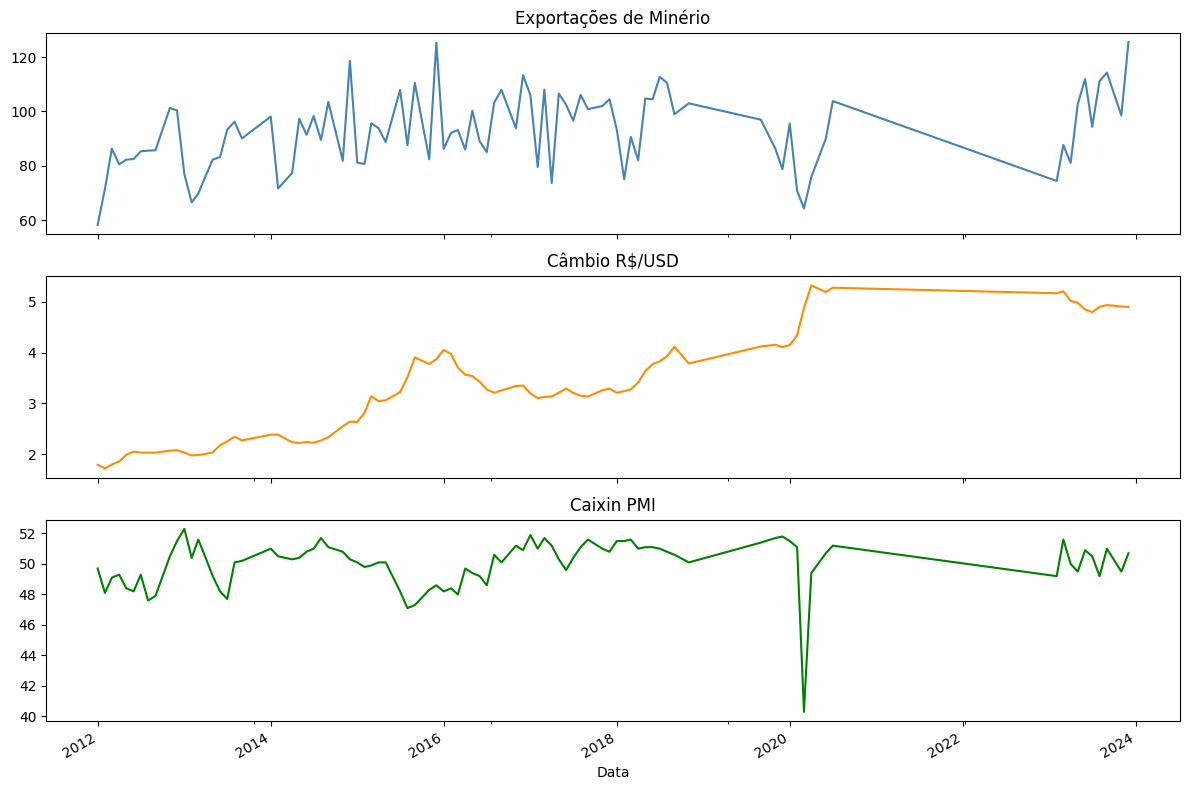

In [ ]:
#Graficos

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

df.plot(x='Data', y='Minerio', ax=axes[0], title='Exportações de Minério', legend=False, color='steelblue')
df.plot(x='Data', y='Cambio',  ax=axes[1], title='Câmbio R$/USD',          legend=False, color='darkorange')
df.plot(x='Data', y='Caixin',  ax=axes[2], title='Caixin PMI',              legend=False, color='green')

plt.tight_layout()
plt.show()

In [ ]:
#Regressão OLS

modelo = smf.ols('Minerio ~ Cambio + Caixin', data=df)
resultado = modelo.fit()
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                Minerio   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     6.788
Date:                Thu, 28 May 2026   Prob (F-statistic):            0.00181
Time:                        04:58:08   Log-Likelihood:                -360.96
No. Observations:                  91   AIC:                             727.9
Df Residuals:                      88   BIC:                             735.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.9720     43.174     -0.416      0.6

Durbin-Watson: 1.5656
(~2 = sem autocorrelação | <1 = autocorrelação positiva | >3 = negativa)


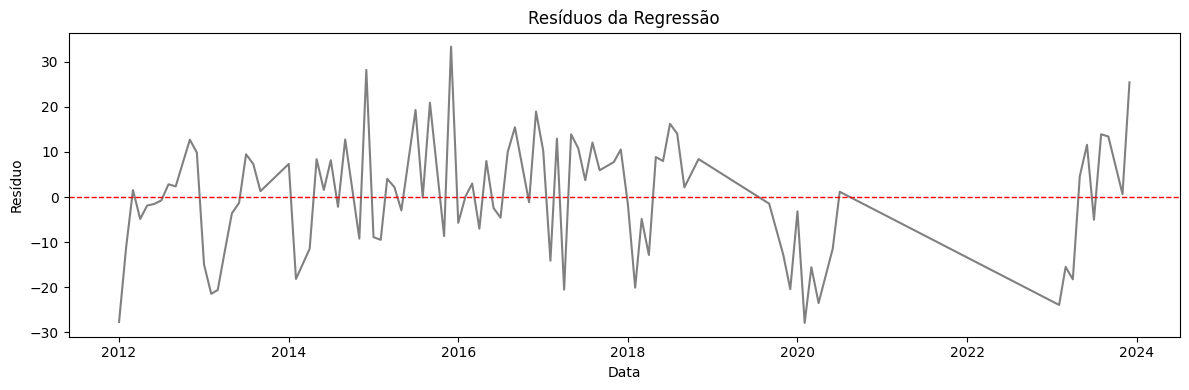


R²          = 0.1337
R² ajustado = 0.1140

Coeficientes:
Intercept   -17.9720
Cambio        3.9652
Caixin        1.9464
dtype: float64

P-valores:
Intercept    0.6782
Cambio       0.0041
Caixin       0.0254
dtype: float64


In [ ]:
#diagnosticos

# Durbin-Watson
dw = durbin_watson(resultado.resid)
print(f"Durbin-Watson: {dw:.4f}")
print("(~2 = sem autocorrelação | <1 = autocorrelação positiva | >3 = negativa)")

# Gráfico de resíduos
plt.figure(figsize=(12, 4))
plt.plot(df['Data'], resultado.resid, color='gray')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos da Regressão')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.tight_layout()
plt.show()

# Resumo dos resultados
print(f"\nR²          = {resultado.rsquared:.4f}")
print(f"R² ajustado = {resultado.rsquared_adj:.4f}")
print(f"\nCoeficientes:")
print(resultado.params.round(4))
print(f"\nP-valores:")
print(resultado.pvalues.round(4))

Teste entre minério e o indice caixin PMI

In [ ]:
modelo_cx = smf.ols('Minerio ~ Caixin', data=df)
resultado_cx = modelo_cx.fit()
print(resultado_cx.summary())

                            OLS Regression Results                            
Dep. Variable:                Minerio   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     4.483
Date:                Thu, 28 May 2026   Prob (F-statistic):             0.0370
Time:                        05:01:48   Log-Likelihood:                -365.25
No. Observations:                  91   AIC:                             734.5
Df Residuals:                      89   BIC:                             739.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.0793     44.652     -0.047      0.9

Durbin-Watson: 1.4352


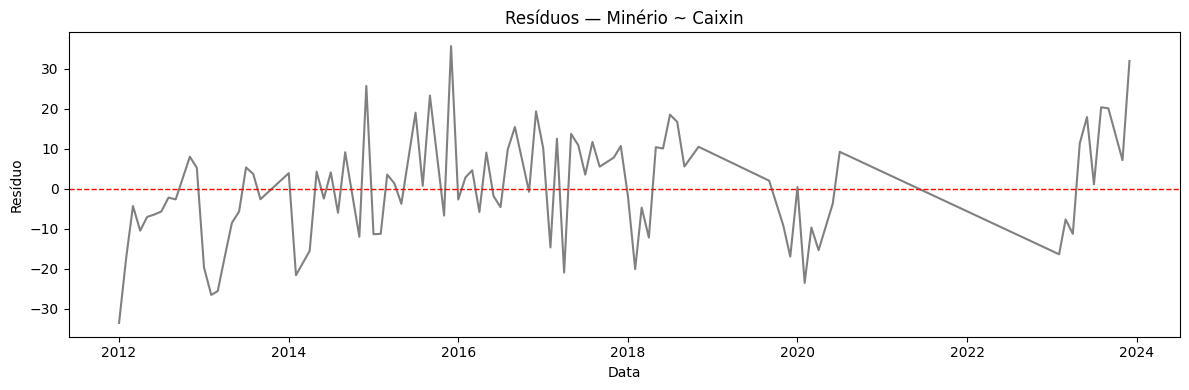


R²          = 0.0480
R² ajustado = 0.0373

Coeficientes:
Intercept   -2.0793
Caixin       1.8884
dtype: float64

P-valores:
Intercept    0.963
Caixin       0.037
dtype: float64


In [ ]:
dw_cx = durbin_watson(resultado_cx.resid)
print(f"Durbin-Watson: {dw_cx:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(df['Data'], resultado_cx.resid, color='gray')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos — Minério ~ Caixin')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.tight_layout()
plt.show()

print(f"\nR²          = {resultado_cx.rsquared:.4f}")
print(f"R² ajustado = {resultado_cx.rsquared_adj:.4f}")
print(f"\nCoeficientes:")
print(resultado_cx.params.round(4))
print(f"\nP-valores:")
print(resultado_cx.pvalues.round(4))